In [66]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

data_path = "../data/mixedtype-wafer-defect-datasets/Wafer_Map_Datasets.npz"

data = np.load(data_path)
images = data["arr_0"]
labels = data["arr_1"]

* **[‘arr_0’]:** Defect data of mixed-type wafer map, **0 means blank spot**, **1 represents normal die that passed the electrical test**, and **2 represents broken die that failed the electrical test**. The data shape is 52×52.
* **[‘arr_1’]:** Mixed-type wafer map defect label, **using one-hot encoding**, a total of 8 dimensions, corresponding to the 8 basic types of wafer map defects (single defect).

# Data Exploration

## Labels

In [67]:
# Basic summary of labels
print("Labels shape:", labels.shape)
print("Total entries:", labels.shape[0])

# Unique values across entire labels array
unique_vals = np.unique(labels)
print("Unique values:", unique_vals)
print("Number of unique values:", unique_vals.size)

# Missing data check
missing_count = np.isnan(labels).sum()
print("Missing values (NaN) count:", missing_count)

# Show a few example label rows
examples_df = pd.DataFrame(labels[:5])
print("Example label rows:")
display(examples_df)

# Unique row patterns count
unique_rows = np.unique(labels, axis=0)
print("Number of unique label patterns:", unique_rows.shape[0])

Labels shape: (38015, 8)
Total entries: 38015
Unique values: [0 1]
Number of unique values: 2
Missing values (NaN) count: 0
Example label rows:


,0,1,2,3,4,5,6,7
0,1,0,1,0,0,0,1,0
1,1,0,1,0,0,0,1,0
2,1,0,1,0,0,0,1,0
3,1,0,1,0,0,0,1,0
4,1,0,1,0,0,0,1,0


Number of unique label patterns: 38


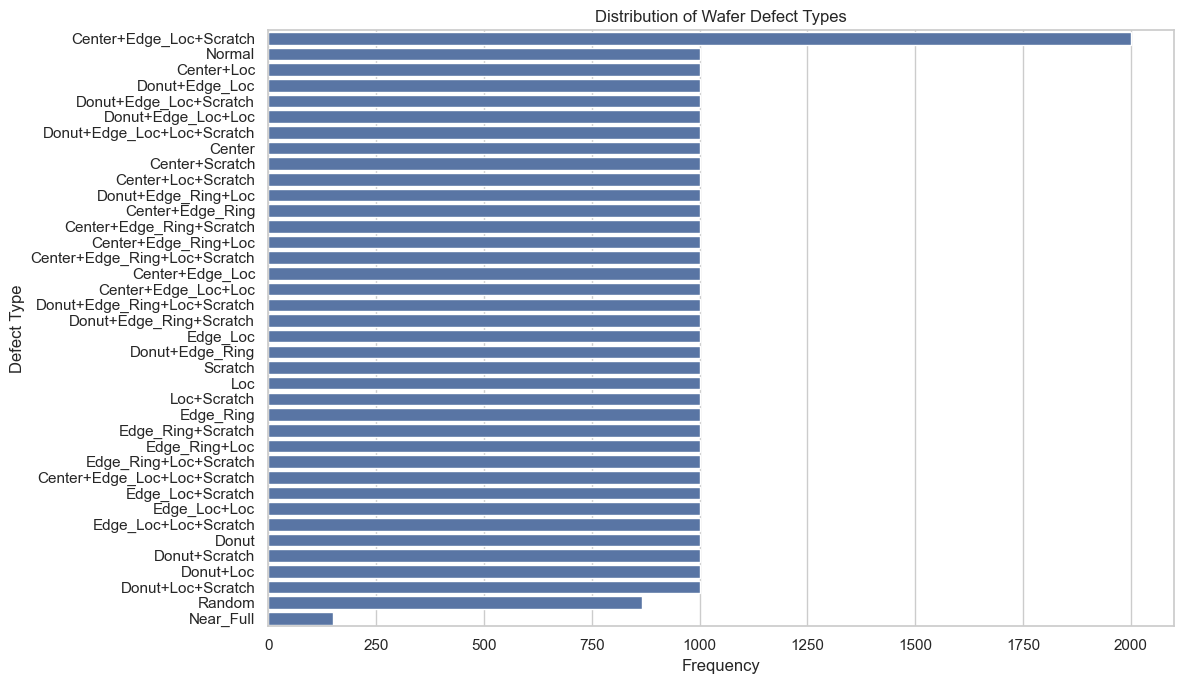

In [68]:
label_mapping = {
    "00000000": "Normal",
    "10000000": "Center",
    "01000000": "Donut",
    "00100000": "Edge_Loc",
    "00010000": "Edge_Ring",
    "00001000": "Loc",
    "00000100": "Near_Full",
    "00000010": "Scratch",
    "00000001": "Random",
    "10100000": "Center+Edge_Loc",
    "10010000": "Center+Edge_Ring",
    "10001000": "Center+Loc",
    "10000010": "Center+Scratch",
    "01100000": "Donut+Edge_Loc",
    "01010000": "Donut+Edge_Ring",
    "01001000": "Donut+Loc",
    "01000010": "Donut+Scratch",
    "00101000": "Edge_Loc+Loc",
    "00100010": "Edge_Loc+Scratch",
    "00011000": "Edge_Ring+Loc",
    "00010010": "Edge_Ring+Scratch",
    "00001010": "Loc+Scratch",
    "10101000": "Center+Edge_Loc+Loc",
    "10100010": "Center+Edge_Loc+Scratch",
    "10011000": "Center+Edge_Ring+Loc",
    "10010010": "Center+Edge_Ring+Scratch",
    "10001010": "Center+Loc+Scratch",
    "01101000": "Donut+Edge_Loc+Loc",
    "01100010": "Donut+Edge_Loc+Scratch",
    "01011000": "Donut+Edge_Ring+Loc",
    "01010010": "Donut+Edge_Ring+Scratch",
    "01001010": "Donut+Loc+Scratch",
    "00101010": "Edge_Loc+Loc+Scratch",
    "00011010": "Edge_Ring+Loc+Scratch",
    "10101010": "Center+Edge_Loc+Loc+Scratch",
    "10011010": "Center+Edge_Ring+Loc+Scratch",
    "01101010": "Donut+Edge_Loc+Loc+Scratch",
    "01011010": "Donut+Edge_Ring+Loc+Scratch",
}

# Convert one-hot vectors to string keys
label_str = ["".join(map(str, map(int, row))) for row in labels]
label_names = [label_mapping.get(key, "Unknown") for key in label_str]

# Count frequency
label_counts = Counter(label_str)

# Create DataFrame with label names
label_df = (
    pd
    .DataFrame([
        {"OneHot": k, "Count": v, "LabelName": label_mapping.get(k, "Unknown")} for k, v in label_counts.items()
    ])
    .sort_values("OneHot")
    .reset_index(drop=True)
)

# plot label distribution with seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))
sns.barplot(data=label_df, x="Count", y="LabelName", order=label_df.sort_values("Count", ascending=False)["LabelName"])
plt.xlabel("Frequency")
plt.ylabel("Defect Type")
plt.title("Distribution of Wafer Defect Types")
plt.tight_layout()
plt.show()

From the plot above, we can see that for most of the defect labels we have 1,000 images including the normal wafers. But for `Center+Edge_loc+Scratch` we have 2,000 images, for `Random` around 800 and for `Near_Full` an under representation of ~200 images.

## Images

In [69]:
# Basic summary of images array
print("Images shape:", images.shape)
print("Total entries:", images.shape[0])
print("Single image shape:", images[0].shape)
print("Dtype:", images.dtype)

# Missing data check
missing_count_images = np.isnan(images).sum()
print("Missing values (NaN) count:", missing_count_images)

# Unique values across entire images array
unique_vals_images = np.unique(images)
print("Unique values:", unique_vals_images)
print("Number of unique values:", unique_vals_images.size)

# Count images with at least one pixel value of 3
images_with_3 = np.sum(np.any(images == 3, axis=(1, 2)))
print(f"Images with at least one pixel value of 3: {images_with_3}")

# in the images that have at least one pixel value of 3, tell me the average of many pixels have the value 3
images_with_3_pixels = images[np.any(images == 3, axis=(1, 2))]
count_3_pixels = np.sum(images_with_3_pixels == 3)
average_3_pixels = count_3_pixels / images_with_3
print(f"Average number of pixels with value 3 in those images: {average_3_pixels}")

# Show a few example images (as arrays)
sample_images = images[:3]
print("Sample image arrays:")
for i, img in enumerate(sample_images, start=1):
    print(f"Image {i} shape: {img.shape}")
    print(img)

Images shape: (38015, 52, 52)
Total entries: 38015
Single image shape: (52, 52)
Dtype: int32
Missing values (NaN) count: 0
Unique values: [0 1 2 3]
Number of unique values: 4
Images with at least one pixel value of 3: 105
Average number of pixels with value 3 in those images: 2.038095238095238
Sample image arrays:
Image 1 shape: (52, 52)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Image 2 shape: (52, 52)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Image 3 shape: (52, 52)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


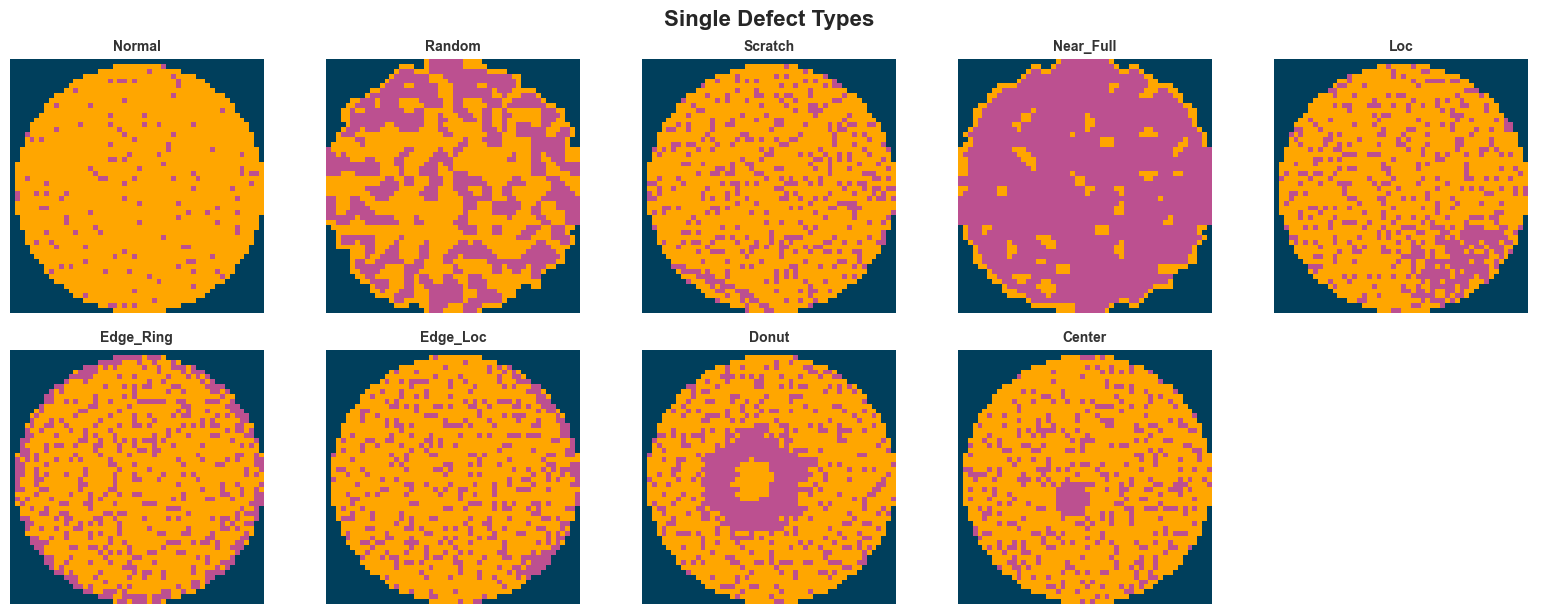

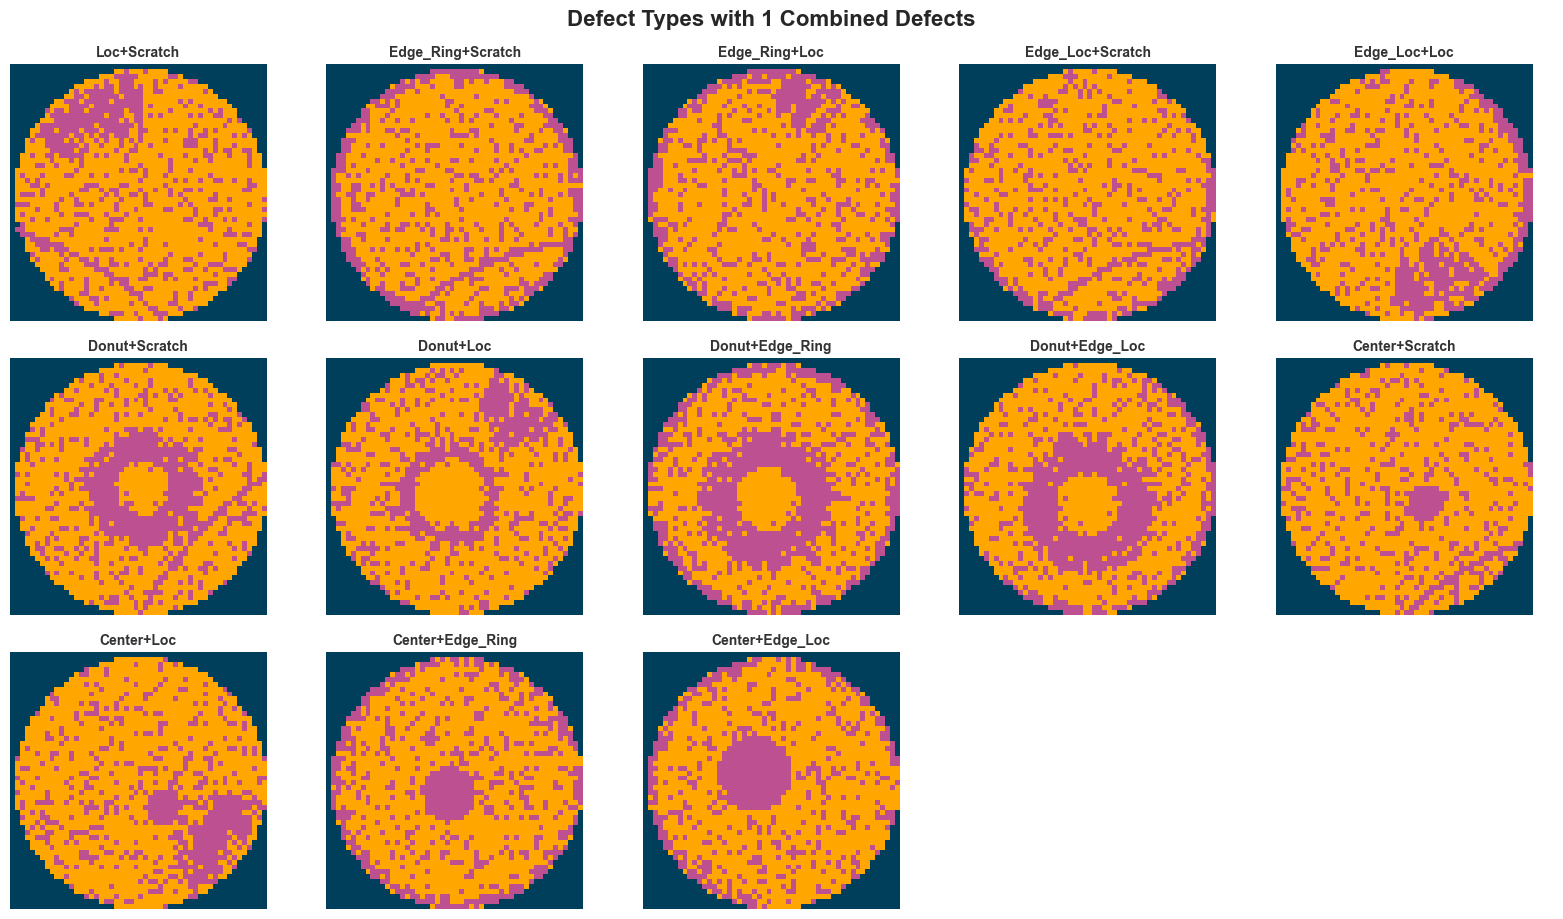

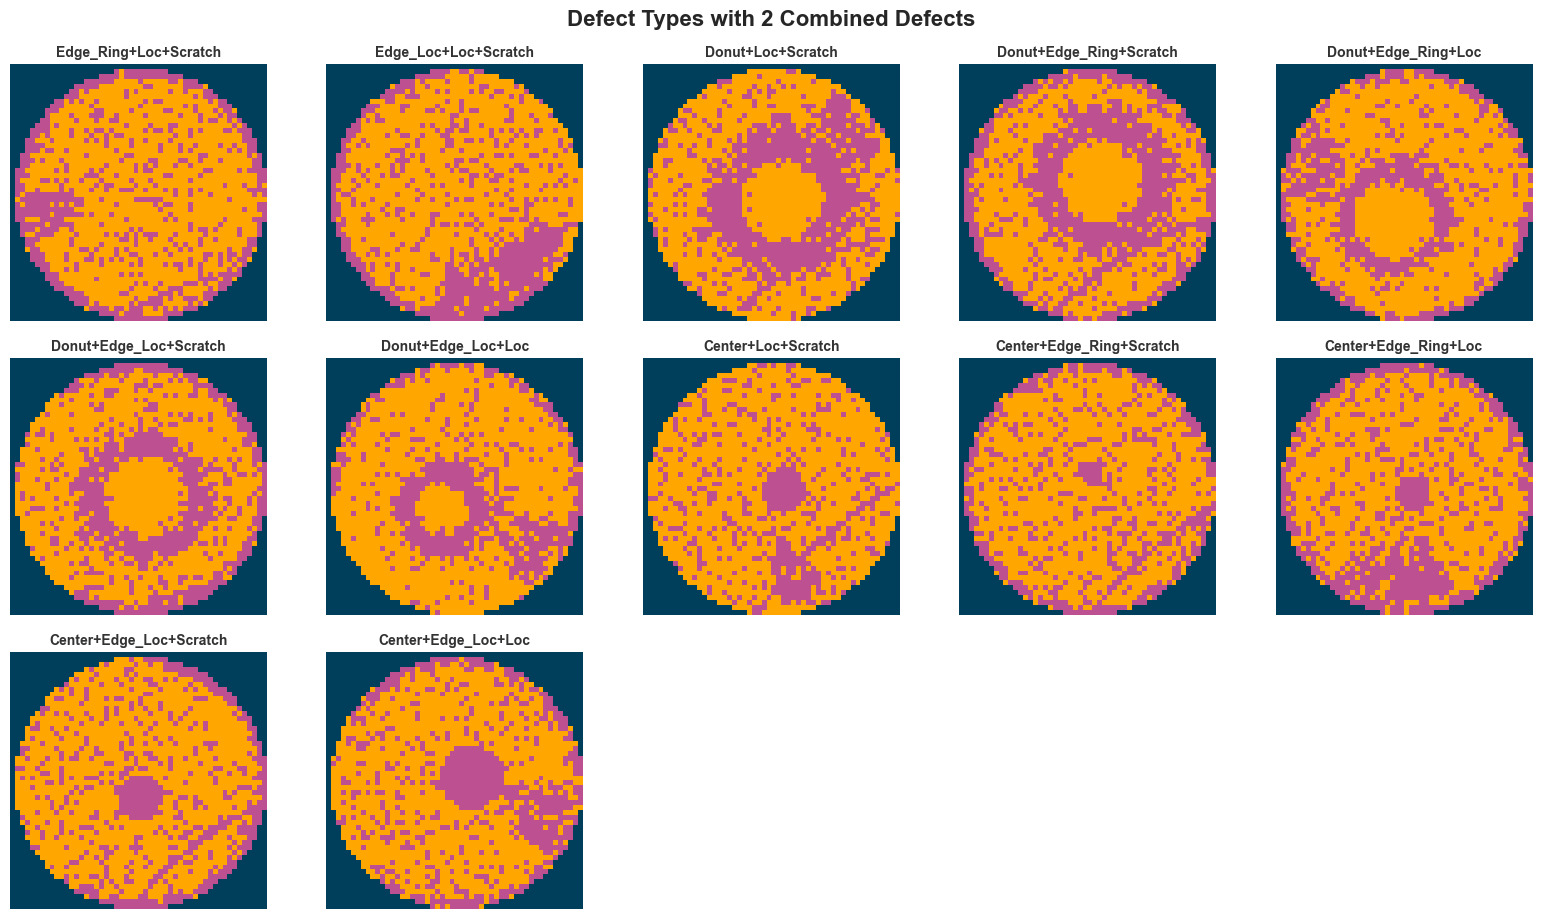

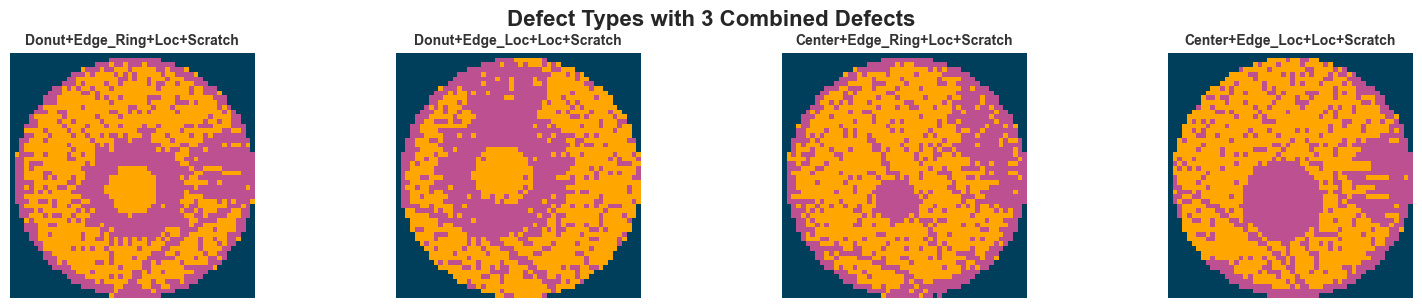

In [71]:
def convert_to_rgb(image):
    height, width = image.shape
    rgb_image = np.zeros((height, width, 3), dtype=np.uint8)
    rgb_image[image == 0] = [0, 63, 92]
    rgb_image[image == 1] = [255, 166, 0]
    rgb_image[image == 2] = [188, 80, 144]
    return rgb_image


# Separate labels by number of defects (number of '+' in label name)
unique_labels = label_df["LabelName"].tolist()

labels_by_defect_count = {0: [], 1: [], 2: [], 3: []}

for label_name in unique_labels:
    plus_count = label_name.count("+")
    labels_by_defect_count[plus_count].append(label_name)

# Plot each group separately
sns.set_theme(style="white")

for defect_count, labels_group in labels_by_defect_count.items():
    if not labels_group:
        continue

    n_labels = len(labels_group)
    n_cols = min(5, n_labels)
    n_rows = (n_labels + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
    axes = [axes] if n_labels == 1 else axes.flatten() if n_rows > 1 else axes

    for idx, label_name in enumerate(labels_group):
        label_idx = label_names.index(label_name)
        rgb_image = convert_to_rgb(images[label_idx])

        axes[idx].imshow(rgb_image)
        axes[idx].set_title(label_name, fontsize=10, fontweight="bold", color="#333333")
        axes[idx].axis("off")
        axes[idx].spines["top"].set_visible(False)
        axes[idx].spines["right"].set_visible(False)
        axes[idx].spines["bottom"].set_visible(False)
        axes[idx].spines["left"].set_visible(False)

    # Hide unused subplots
    for idx in range(n_labels, len(axes)):
        axes[idx].axis("off")

    fig.patch.set_facecolor("white")
    plt.axis("off")
    plt.tight_layout()

    # Add a suptitle for the group
    if defect_count == 0:
        fig.suptitle("Single Defect Types", fontsize=16, fontweight="bold", y=1.02)
    else:
        fig.suptitle(f"Defect Types with {defect_count} Combined Defects", fontsize=16, fontweight="bold", y=1.02)

    plt.show()